The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
41
(410, 41)
[1.05778918e+05 3.52010422e+04 2.40531143e+04 1.59418728e+04
 3.19463954e+03 7.02981525e-12]
[[ 1.01144359e-01  4.77415444e-02  3.48196241e-02  1.58849204e-01
   1.17622417e-01  5.27263940e-02  7.31212297e-03  5.85547360e-02
   5.92714931e-03  4.65730530e-02  7.28850098e-02  8.58201055e-03]
 [-3.20290471e-01 -1.51181557e-01 -1.10262143e-01 -5.03022480e-01
  -3.72470986e-01 -1.66966914e-01 -2.31550561e-02 -1.85423331e-01
  -1.87693062e-02 -1.47481335e-01 -2.30802531e-01 -2.71763667e-02]
 [-8.85711488e-03  3.84611611e-01  2.31151708e-01  3.98717098e-01
   6.53484540e-02 -2.53808476e-01  3.60233915e-02  8.45352952e-03
  -2.16176099e-01 -3.07584028e-01  2.26685703e-01 -2.00768578e-01]
 [-6.74295729e-02 -3.18276963e-02 -2.32130827e-02 -1.05899469e-01
  -7.84149444e-02 -3.51509293e-02 -4.87474865e-03 -3.90364907e-02
  -3.95143288e-03 -3.10487020e-02 -4.85900065e-02 -5.72134037e-03]
 [-6.71887

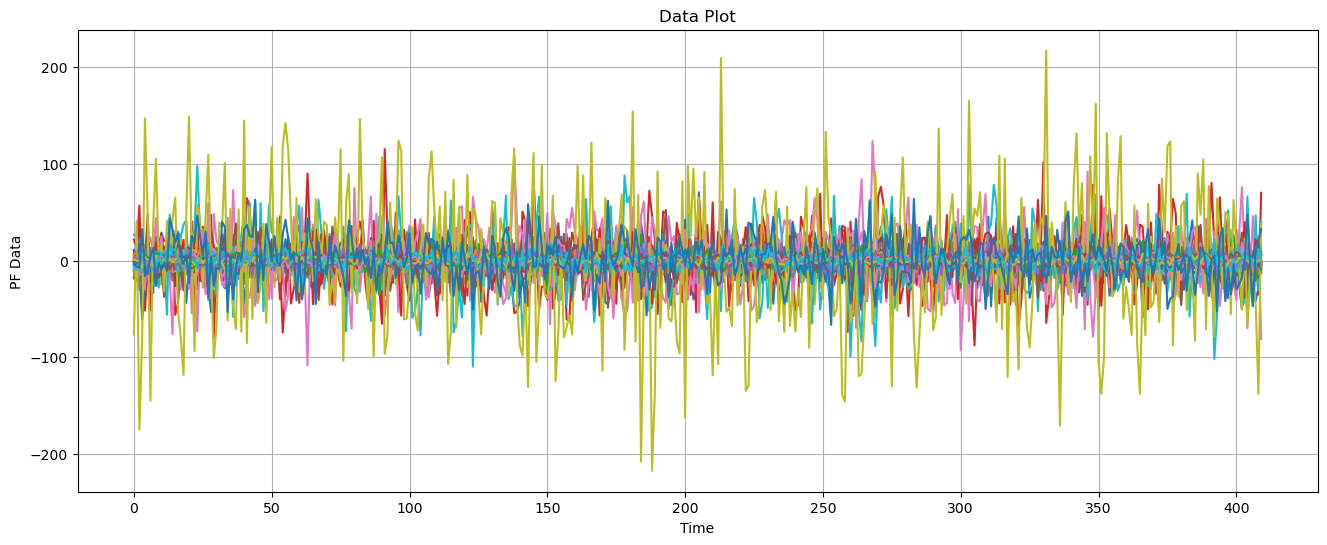

In [21]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import networkx as nx
import lib.plotGraph as plotGraph
import lib.ioFile as ioFile
import lib.powerfun as powerfun
import lib.biconnect as biconnect
import lib.cycle as cycle
import lib.graph as graph
import lib.parasLearn as parasLearn


powerID= 30
# Load MATLAB file
file_name= f'matpower/test_data/DC_case{powerID}_.mat' #14, 118, 57, 30
# Access a variable inside the .mat file
_, phaseData, H, A= ioFile.read_mat_power(file_name, normalize= False)
m= H.shape[0]
n= H.shape[1]
print(m)
stdOfNoise= 1e-9
newDataNp= powerfun.generate_random_power_flow(H, m*10)
pfData, _=ioFile.read_excel_power(file_path= f'data/results2/step-change/results{powerID}.xlsx', id1= 0, id2= 0)
# newDataNp= pfData[:300, :]
newDataNp= powerfun.add_noise_to_data(newDataNp, stdOfNoise)

print(newDataNp.shape)
ChoosenIDX= [11, 12, 18, 7, 8, 14]
tmpStdNewData= newDataNp[:, ChoosenIDX]-np.mean(newDataNp[:, ChoosenIDX], axis=1, keepdims= True)
covNewData= tmpStdNewData.T.dot(tmpStdNewData)
U, S, V= np.linalg.svd(covNewData.T, full_matrices=True)
print(S)
U, S, V= np.linalg.svd(newDataNp[:, :].T, full_matrices=True)
nullTmp= U[:, 29:]
print(nullTmp)
print(nullTmp.dot(nullTmp.T)[0, :])

plt.figure(figsize=(16, 6))
for i in range(newDataNp.shape[1]):
    plt.plot(newDataNp[:, i], label=i)
plt.title('Data Plot')
plt.xlabel('Time')
plt.ylabel('PF Data')
# plt.legend()
plt.grid(True)
plt.show()

In [2]:

biconnectedList, cosSim= biconnect.gen_biconnectedlist(newDataNp)
print(biconnectedList)
print("m:", m)
# print(np.round(cosSim, 1))
biconnected_components_dict= cycle.get_biconnected_components_dict(newDataNp, cosSim, biconnectedList)
# print(biconnected_components_dict)
predParas= parasLearn.paras_learning(biconnected_components_dict, newDataNp)
P= np.sum(np.abs(H), axis= 1, keepdims= True)/2
print((predParas/P).T)
lenOfMaxBi= 0
maxBi= None
for biconnected in biconnectedList:
    if len(biconnected)>lenOfMaxBi:
        maxBi= biconnected
        lenOfMaxBi= len(biconnected)
# print(lenOfMaxBi)


LEN: 20
[[13], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19]]
m: 20
Num of links: 19
Num of Detected links: 19
Circles Detected: 7
Run loops: 20
m*log(m): 55.94434060416236
Combine biconnected: 1

[[0.54258144 0.54257127 0.54269906 0.54270387 0.54263884 0.54257407
  0.54264812 0.54276479 0.54289467 0.54293931 0.54272746 0.54254055
  0.54261401 0.         0.54282781 0.54291884 0.54311882 0.54274726
  0.54248817 0.54301187]]


In [404]:
# # predicted parameters precision
# pfData, _=ioFile.read_excel_power(file_path= f'data/results2/step-change/results{powerID}.xlsx', id1= 0, id2= 0)
# newDataNp= powerfun.generate_random_power_flow(H, 5)
# newDataNp= pfData[:n-1, :]
# stdOfPars= []
# stdOfNoises= []
# for i in tqdm(range(100)):
#     stdOfNoise= 1e-4*(i+1)
#     numOfRun= 50
#     sumStdOfPara= 0
#     for _ in range(numOfRun):
#         newDataNpT= powerfun.add_noise_to_data(newDataNp, stdOfNoise)
#         predParas= parasLearn.paras_learning(biconnected_components_dict, newDataNpT)
#         maxBiRatio= (predParas[maxBi]/P[maxBi]).T
#         sumStdOfPara+= np.std(maxBiRatio)
#     stdOfNoises.append(stdOfNoise)
#     # print(maxBiRatio)
#     stdOfPars.append(sumStdOfPara/numOfRun)

In [75]:
stdOfPars= []
numOfdatas= []
pfData, _=ioFile.read_excel_power(file_path= f'data/results2/step-change/results{powerID}.xlsx', id1= 0, id2= 0)
for i in tqdm(range(n-1, 800, 10)):
    newDataNp= pfData[:i, :].copy()
    numOfRun= 40
    sumStdOfPara= 0
    stdOfNoise= 1e-2
    for _ in range(numOfRun):
        newDataNpT= powerfun.add_noise_to_data(newDataNp, stdOfNoise)
        predParas= parasLearn.paras_learning(biconnected_components_dict, newDataNpT)
        maxBiRatio= (predParas[maxBi]/P[maxBi]).T
        sumStdOfPara+= np.std(maxBiRatio)
    stdOfPars.append(sumStdOfPara/numOfRun)
    numOfdatas.append(i)

100%|██████████| 79/79 [00:00<00:00, 186.98it/s]


In [76]:
# plt.plot(numOfdatas, stdOfPars)
plt.plot(plotResults[0][0], plotResults[0][1], label="IEEE 14")
plt.plot(plotResults[1][0], plotResults[1][1], label="IEEE 30")
plt.plot(plotResults[2][0], plotResults[2][1], label="IEEE 57")
plt.plot(plotResults[3][0], plotResults[3][1], label="IEEE 118")
plt.legend(fontsize= 12)
plt.ylabel("$\sigma(\hat{P}_{maxbi}/P_{maxbi})$", fontsize= 15)
plt.xlabel("Number of pf data($T$)", fontsize= 15)
plt.yscale("log")
# plt.xscale("log")

NameError: name 'plotResults' is not defined

In [433]:
import json

# fileName= "data/code_save/error_vs_numberOfData.json"
fileName= "data/code_save/error_vs_noiseError.json"

# with open(fileName, "w") as file:
#     json.dump(plotResults, file)

with open(fileName, "r") as file:
    plotResults = json.load(file)


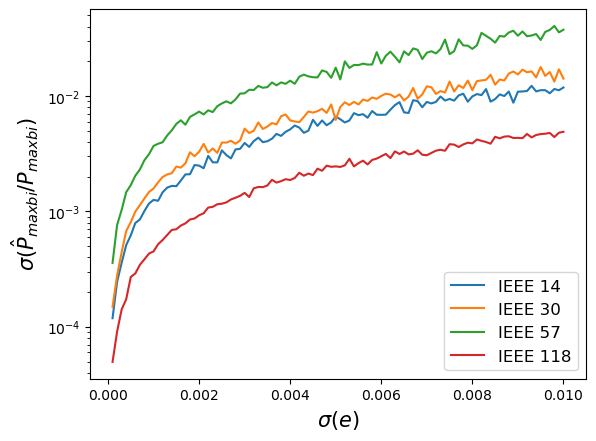

In [434]:
# plt.plot(stdOfNoises, stdOfPars)
plt.plot(plotResults[0][0], plotResults[0][1], label="IEEE 14")
plt.plot(plotResults[1][0], plotResults[1][1], label="IEEE 30")
plt.plot(plotResults[2][0], plotResults[2][1], label="IEEE 57")
plt.plot(plotResults[3][0], plotResults[3][1], label="IEEE 118")
plt.legend(fontsize= 12)
plt.ylabel("$\sigma(\hat{P}_{maxbi}/P_{maxbi})$", fontsize= 15)
plt.xlabel("$\sigma(e)$", fontsize= 15)
plt.yscale("log")
# plt.xscale("log")

In [414]:
# plotResults= []
print(len(plotResults))


1


In [430]:
# plotResults.append((stdOfNoises, stdOfPars))
plotResults.append((numOfdatas, stdOfPars))


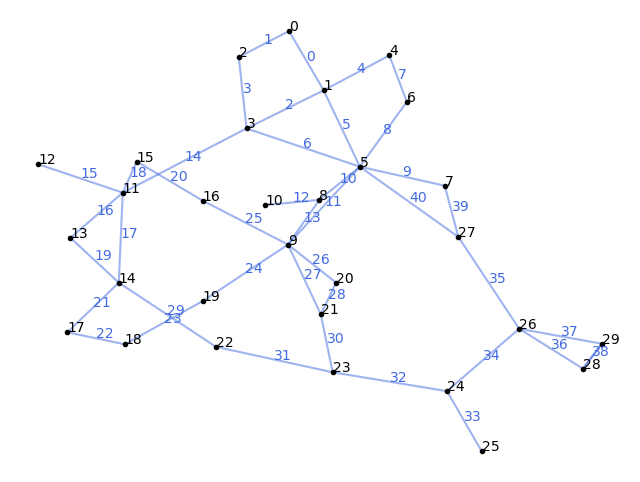

In [10]:

G, node_pair2id= graph.from_A_to_G(A)
G= G.to_undirected()
biconnected_components = list(nx.biconnected_components(G))
largest_bcc = list(max(biconnected_components, key=len))
plotGraph.plot_spring_layout(G, label= True, label_edge= True, node_pair2id= node_pair2id)